In [1]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
import pandas as pd
from collections import Counter
from tqdm import tqdm
from itertools import combinations
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import numpy as np
import os

# Cargar Datos

In [6]:
file_path = r"..\data\results\ciencia_chunks.xlsx"
fragmentos_ciencia = pd.read_excel(file_path, engine='openpyxl')

file_path2 = r"..\data\processed\corpus_cleaned.xlsx"
corpus_cleaned = pd.read_excel(file_path2, engine='openpyxl')

chunks_df = pd.read_parquet(r"..\data\processed\chunks.parquet")

In [5]:
corpus_cleaned.head(3)

,Diario,Autor,Fecha,Título,Texto,Vínculo,ID,Texto_limpio
0,El Espectador,Gonzalo Hernández,2018-01-01,Fajardo: para nada tibio,"La Coalición Colombia –Partido Alianza Verde, ...",https://web.archive.org/web/20180102104221/htt...,1,"La Coalición Colombia Partido Alianza Verde, P..."
1,El Espectador,Eduardo Barajas Sandoval,2018-01-01,Macedonia de Norte,Las interpretaciones de la historia sirven com...,https://web.archive.org/web/20180102104221/htt...,2,Las interpretaciones de la historia sirven com...
2,El Espectador,Daniel Emilio Rojas Castro,2018-01-01,El nacionalismo según Vargas Llosa,La semana pasada Mario Vargas Llosa publicó un...,https://web.archive.org/web/20180102104221/htt...,3,La semana pasada Mario Vargas Llosa publicó un...


# Cargar modelos

In [4]:
tokenizer = AutoTokenizer.from_pretrained("Babelscape/wikineural-multilingual-ner")
model = AutoModelForTokenClassification.from_pretrained("Babelscape/wikineural-multilingual-ner")
ner_pipeline = pipeline("ner", model=model, tokenizer=tokenizer, grouped_entities=True)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: Babelscape/wikineural-multilingual-ner
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
c:\Users\karen\anaconda3\Lib\site-packages\transformers\pipelines\token_classification.py:177: UserWarning: `grouped_entities` is deprecated and will be removed in version v5.0.0, defaulted to `aggregation_strategy="AggregationStrategy.SIMPLE"` instead.
  warnings.warn(


In [7]:
def extraer_entidades(texto, max_palabras=400):
    """
    Extrae entidades nombradas de un texto largo usando el modelo NER.
    Divide automáticamente el texto en fragmentos (máx. 400 palabras)
    para evitar el límite de tokens del modelo.

    Devuelve: lista de tuplas (tipo_entidad, texto_entidad)
    """
    entidades = []
    try:
        palabras = texto.split()
        for i in range(0, len(palabras), max_palabras):
            fragmento = " ".join(palabras[i:i + max_palabras])
            resultados = ner_pipeline(fragmento)
            for r in resultados:
                tipo = r.get("entity_group", "").strip()
                nombre = r.get("word", "").strip()
                if tipo and nombre:
                    entidades.append((tipo, nombre))
    except Exception as e:
        print(f"⚠️ Error procesando texto: {e}")
    return entidades

# Extraer entidades general

In [8]:
corpus_cleaned.head(2)

,Diario,Autor,Fecha,Título,Texto,Vínculo,ID,Texto_limpio
0,El Espectador,Gonzalo Hernández,2018-01-01,Fajardo: para nada tibio,"La Coalición Colombia –Partido Alianza Verde, ...",https://web.archive.org/web/20180102104221/htt...,1,"La Coalición Colombia Partido Alianza Verde, P..."
1,El Espectador,Eduardo Barajas Sandoval,2018-01-01,Macedonia de Norte,Las interpretaciones de la historia sirven com...,https://web.archive.org/web/20180102104221/htt...,2,Las interpretaciones de la historia sirven com...


In [ ]:
tqdm.pandas(desc="Extrayendo entidades")
corpus_cleaned['entidades'] = corpus_cleaned['Texto_limpio'].progress_apply(extraer_entidades)

In [8]:
resultado_general = corpus_cleaned[["ID", "Autor", "Fecha", "Texto_limpio", "entidades"]]

resultado_general.to_parquet(r"..\data\results\general_ner.parquet", index=False)

# Extraer entidades ciencia

In [5]:
tqdm.pandas(desc="Extrayendo entidades")
fragmentos_ciencia["entidades"] = fragmentos_ciencia["texto_chunk"].progress_apply(extraer_entidades)

Extrayendo entidades: 100%|██████████| 4287/4287 [00:00<00:00, 33586.96it/s]

⚠️ Error procesando texto: name 'ner_pipeline' is not defined
⚠️ Error procesando texto: name 'ner_pipeline' is not defined
⚠️ Error procesando texto: name 'ner_pipeline' is not defined
⚠️ Error procesando texto: name 'ner_pipeline' is not defined
⚠️ Error procesando texto: name 'ner_pipeline' is not defined
⚠️ Error procesando texto: name 'ner_pipeline' is not defined
⚠️ Error procesando texto: name 'ner_pipeline' is not defined
⚠️ Error procesando texto: name 'ner_pipeline' is not defined
⚠️ Error procesando texto: name 'ner_pipeline' is not defined
⚠️ Error procesando texto: name 'ner_pipeline' is not defined
⚠️ Error procesando texto: name 'ner_pipeline' is not defined
⚠️ Error procesando texto: name 'ner_pipeline' is not defined
⚠️ Error procesando texto: name 'ner_pipeline' is not defined
⚠️ Error procesando texto: name 'ner_pipeline' is not defined
⚠️ Error procesando texto: name 'ner_pipeline' is not defined
⚠️ Error procesando texto: name 'ner_pipeline' is not defined
⚠️ Error

In [13]:
resultado = fragmentos_ciencia[["chunk_id", "id_doc", "texto_chunk", "categorias_detectadas", "entidades"]]

resultado.to_parquet(r"..\data\results\fragmentos_ciencia_ner.parquet", index=False)

# Leer NER Creado

In [3]:
#df = pd.read_parquet(r"..\data\results\general_ner.parquet")
df = pd.read_parquet(r"..\data\results\fragmentos_ciencia_ner.parquet")
df

,chunk_id,id_doc,texto_chunk,categorias_detectadas,entidades
0,1,6,le reconoce a las ideas de esas mismas persona...,"[('Ciencias_ambientales_ingenieria', 0.4655396...","[[LOC, Pacífico], [MISC, masacre de Bojayá], [..."
1,0,11,El método es sencillo. Primero tensar un poco ...,"[('Ciencias_polucion_catastrofes_seguridad', 0...","[[PER, Bertrand Russell]]"
2,1,29,otra cara de la moneda de Cali y la opinión pú...,"[('Ciencias_polucion_catastrofes_seguridad', 0...","[[LOC, Cali], [LOC, Cali], [MISC, Feria], [MIS..."
3,0,31,2018 será un año muy movido en ciberpolítica. ...,[('Ciencia_Administracion_ciencia_investigacio...,"[[LOC, América Latina], [LOC, América Latina]]"
4,1,35,"comerán sus palabras de tiempos furiosos, fabr...","[('Ciencias_polucion_catastrofes_seguridad', 0...","[[MISC, Congreso], [MISC, Reyes Magos]]"
...,...,...,...,...,...
4282,2,13671,de personas con discapacidad y que más del 70 ...,"[('Ciencias_ambientales_ingenieria', 0.4059691...","[[LOC, Bogotá], [ORG, ##eno], [LOC, Distrito],..."
4283,3,13672,de especies animales y vegetales. Ese es el ho...,"[('Ciencias_Geografia_oceanografia', 0.4281239...","[[LOC, Cajamarca], [LOC, Santurbán], [MISC, Ac..."
4284,0,13676,La pregunta de si los animales también piensan...,"[('Ciencias_naturales', 0.4191318154335022)]","[[PER, Jean Piaget], [PER, Aristóteles], [PER,..."
4285,2,13676,"idea atrevida sobre la que no hay consenso, es...","[('Ciencias_naturales', 0.4115794897079468), (...","[[PER, Voltaire], [PER, Rodolfo Llinás], [PER,..."


In [10]:
df['entidades'][10]

array([array(['PER', 'Bertrand Russell'], dtype=object),
       array(['PER', 'Tocqueville'], dtype=object)], dtype=object)

# Analizar entidades

In [4]:
# ---------- 1. APLANAR ENTIDADES ----------
# cada fila tiene lista de tuplas (tipo, nombre)
todas = []
for lista in df["entidades"]:
    for tipo, nombre in lista:
        if isinstance(tipo, str) and isinstance(nombre, str):
            todas.append((tipo, nombre.strip()))

df_tipos = pd.DataFrame(todas, columns=["Tipo", "Entidad"])
df_tipos["Frecuencia"] = 1

In [5]:
# ---------- 2. FRECUENCIAS ----------
conteo_tipos = Counter([tipo for tipo, _ in todas])
print("Frecuencia por tipo de entidad:", conteo_tipos)

top_entidades = Counter([nombre for _, nombre in todas]).most_common(20)
df_top = pd.DataFrame(top_entidades, columns=["Entidad", "Frecuencia"])
print("\nTop 10 entidades más mencionadas:\n", df_top.head(20))

Frecuencia por tipo de entidad: Counter({'LOC': 13636, 'ORG': 8346, 'PER': 6661, 'MISC': 4198})

Top 10 entidades más mencionadas:
               Entidad  Frecuencia
0            Colombia        1654
1              Estado         702
2              Bogotá         529
3            Gobierno         434
4      Estados Unidos         335
5               Duque         270
6               China         194
7               Trump         145
8            Congreso         144
9                Farc         142
10           Medellín         131
11             Brasil         129
12  Gobierno Nacional         121
13             España         119
14             Europa         114
15             Caribe         111
16        Universidad         111
17           Amazonia         109
18              Cauca         105
19     América Latina         101


In [6]:
# ---------- 2. FRECUENCIA TOTAL POR TIPO ----------
freq_tipo = (
    df_tipos.groupby("Tipo")["Frecuencia"]
    .sum()
    .reset_index()
    .sort_values(by="Frecuencia", ascending=False)
)
print("Frecuencia total por tipo de entidad:")
print(freq_tipo)


Frecuencia total por tipo de entidad:
   Tipo  Frecuencia
0   LOC       13636
2   ORG        8346
3   PER        6661
1  MISC        4198


C:\Users\karen\AppData\Local\Temp\ipykernel_21684\311646772.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=freq_tipo, x="Tipo", y="Frecuencia", palette=palette)


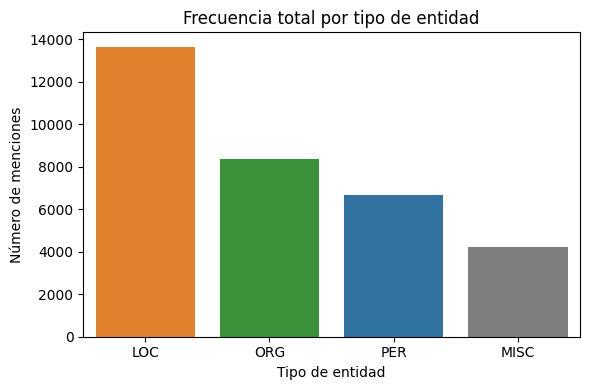

In [7]:
# ---------- 3. GRÁFICO FRECUENCIA POR TIPO ----------
plt.figure(figsize=(6,4))
palette = {"PER": "#1f77b4", "ORG": "#2ca02c", "LOC": "#ff7f0e", "MISC": "#7f7f7f"}
sns.barplot(data=freq_tipo, x="Tipo", y="Frecuencia", palette=palette)
plt.title("Frecuencia total por tipo de entidad")
plt.ylabel("Número de menciones")
plt.xlabel("Tipo de entidad")
plt.tight_layout()
# plt.savefig(OUTPUT_FIG_TIPOS, dpi=300)
plt.show()


In [8]:
# ---------- 4. TOP ENTIDADES POR TIPO ----------
top_por_tipo = (
    df_tipos.groupby(["Tipo", "Entidad"])["Frecuencia"]
    .sum()
    .reset_index()
    .sort_values(by=["Tipo", "Frecuencia"], ascending=[True, False])
)
# Selecciona los top 10 de cada tipo
top10_por_tipo = top_por_tipo.groupby("Tipo").head(10)
print("\n🏆 Top 10 entidades más mencionadas por tipo:")
for tipo in top10_por_tipo["Tipo"].unique():
    subset = top10_por_tipo[top10_por_tipo["Tipo"] == tipo]
    print(f"\n{tipo}:")
    print(subset[["Entidad", "Frecuencia"]].to_string(index=False))


🏆 Top 10 entidades más mencionadas por tipo:

LOC:
       Entidad  Frecuencia
      Colombia        1646
        Estado         699
        Bogotá         529
Estados Unidos         335
         China         193
      Medellín         131
        Brasil         129
        España         119
        Europa         114
        Caribe         111

MISC:
                    Entidad  Frecuencia
                    Twitter          44
             Acuerdo de Paz          35
               Constitución          34
              El Espectador          29
                     Semana          27
                        Ley          26
Plan Nacional de Desarrollo          24
                       Plan          22
                   ##cuerdo          21
                    Navidad          21

ORG:
                         Entidad  Frecuencia
                        Gobierno         353
                            Farc         129
                        Congreso         123
               Gob

In [9]:
# Calcular frecuencia total por entidad y tipo
resumen = (
    df_tipos.groupby(["Tipo", "Entidad"])["Frecuencia"]
    .sum()
    .reset_index()
    .sort_values(by=["Tipo", "Frecuencia"], ascending=[True, False])
)

In [13]:
with pd.ExcelWriter(r"..\data\results\entidades_general.xlsx", engine="openpyxl") as writer:
    resumen.to_excel(writer, sheet_name="Entidades_Frecuencia", index=False)

# Análisis por año ciencia Grafo

In [10]:
# Cargar ambos DataFrames

file_path2 = r"..\data\processed\corpus_cleaned.xlsx"
corpus = pd.read_excel(file_path2, engine='openpyxl')

df = pd.read_parquet(r"..\data\results\fragmentos_ciencia_ner.parquet")

In [11]:
# ---------- Unir año ----------
corpus["ID"] = corpus["ID"].astype(int)
df["id_doc"] = df["id_doc"].astype(int)
corpus["Fecha"] = pd.to_datetime(corpus["Fecha"], errors="coerce")
corpus["Año"] = corpus["Fecha"].dt.year
df = df.merge(corpus[["ID", "Año"]], left_on="id_doc", right_on="ID", how="left").drop(columns=["ID"])
df.head(2)


,chunk_id,id_doc,texto_chunk,categorias_detectadas,entidades,Año
0,1,6,le reconoce a las ideas de esas mismas persona...,"[('Ciencias_ambientales_ingenieria', 0.4655396...","[[LOC, Pacífico], [MISC, masacre de Bojayá], [...",2018
1,0,11,El método es sencillo. Primero tensar un poco ...,"[('Ciencias_polucion_catastrofes_seguridad', 0...","[[PER, Bertrand Russell]]",2018


In [12]:
# ---------- Filtrar fragmentos con palabra “ciencia” o derivados ----------
mask_ciencia = df["texto_chunk"].str.contains(r"\bcienci\w*", flags=re.IGNORECASE, na=False)
df_ciencia = df[mask_ciencia].copy()
#df_ciencia = df
print(f"🧪 Fragmentos con 'ciencia*': {len(df_ciencia)}")

🧪 Fragmentos con 'ciencia*': 437


In [27]:
# ---------- Extraer entidades ORG / PER ----------
def obtener_entidades_org_per(entidades):
    if entidades is None or len(entidades) == 0:
        return []
    return [(e[0], e[1]) for e in entidades if len(e) == 2 and e[0] in ("ORG", "PER") and isinstance(e[1], str)]

In [28]:
ENTIDADES_EXCLUIR = [
    "Organizaciones", "Personas", "Gobierno", "Colombia",
    "Estado", "Mundo", "Nación", "América Latina", "Ciudadanos", "Nacional", "Democracia",
    "Duque", "Caldas", "Manuel Ancizar", "Contraloría", "Misión"
]

# ---------- Crear pares (“ciencia”, entidad) ----------
pares = []
for _, fila in df_ciencia.iterrows():
    año = fila["Año"]
    if pd.isna(año):
        continue
    for tipo, entidad in obtener_entidades_org_per(fila["entidades"]):
        # Filtrar las entidades indeseadas
        if entidad.strip() in ENTIDADES_EXCLUIR:
            continue
        pares.append((año, "ciencia", tipo, entidad.strip()))

df_pares = pd.DataFrame(pares, columns=["Año", "Palabra", "Tipo", "Entidad"])

# ---------- Contar frecuencias ----------
freq = (
    df_pares.groupby(["Año", "Tipo", "Entidad"])
    .size()
    .reset_index(name="frecuencia")
    .sort_values(by=["Año", "frecuencia"], ascending=[True, False])
)

print(f"✅ Total de entidades vinculadas a 'ciencia': {len(freq)}")
print(freq.head(10))

✅ Total de entidades vinculadas a 'ciencia': 1226
      Año Tipo                           Entidad  frecuencia
190  2018  ORG              Universidad Nacional          13
306  2018  PER                           Hawking          13
191  2018  ORG  Universidad Nacional de Colombia          11
38   2018  ORG                       Colciencias           8
186  2018  ORG                       Universidad           7
424  2018  PER                            Santos           7
437  2018  PER                             Trump           6
135  2018  ORG                              OCDE           5
432  2018  PER                   Stephen Hawking           5
74   2018  ORG                               FAO           4


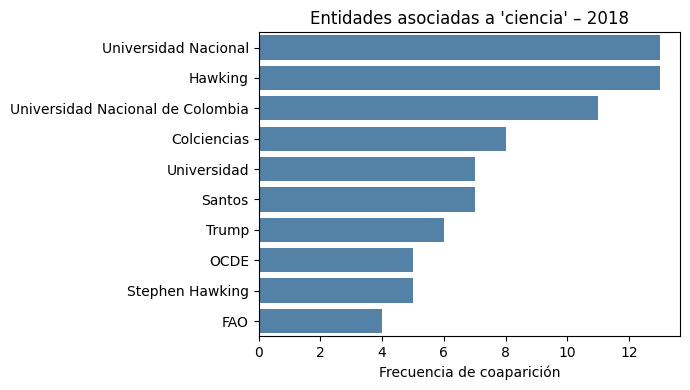

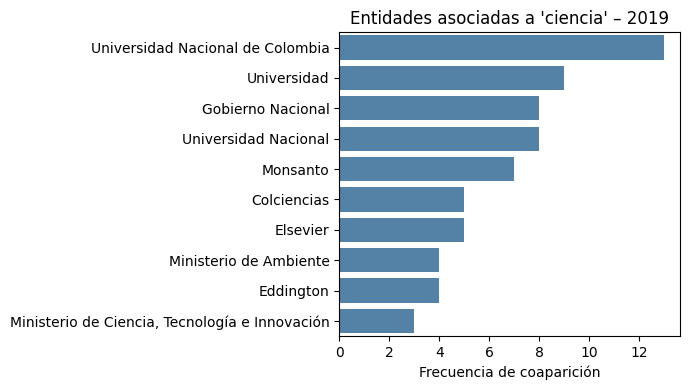

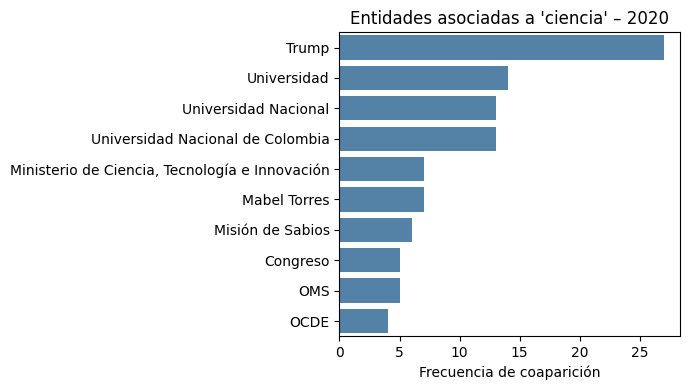

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

for año in [2018, 2019, 2020]:
    top = freq[freq["Año"] == año].head(10)
    plt.figure(figsize=(7,4))
    sns.barplot(data=top, y="Entidad", x="frecuencia", color="steelblue")
    plt.title(f"Entidades asociadas a 'ciencia' – {año}")
    plt.xlabel("Frecuencia de coaparición")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

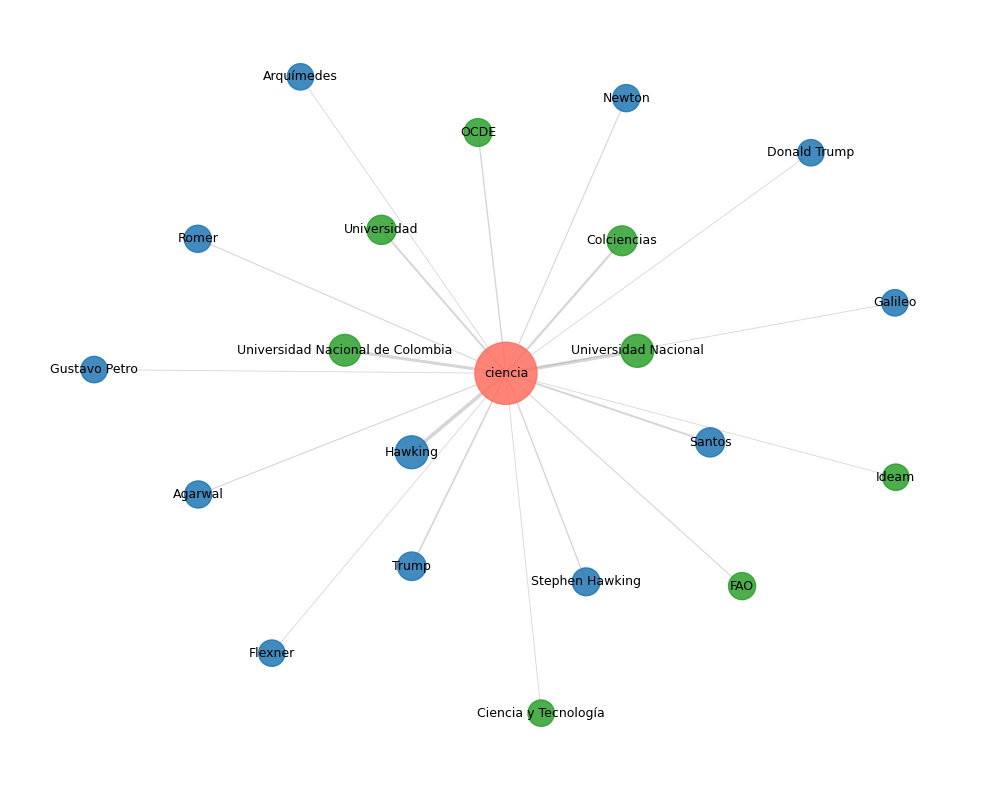

💾 Grafo guardado: ..\reports\ideas PAPERS\figures\grafo_ciencia_2018.png


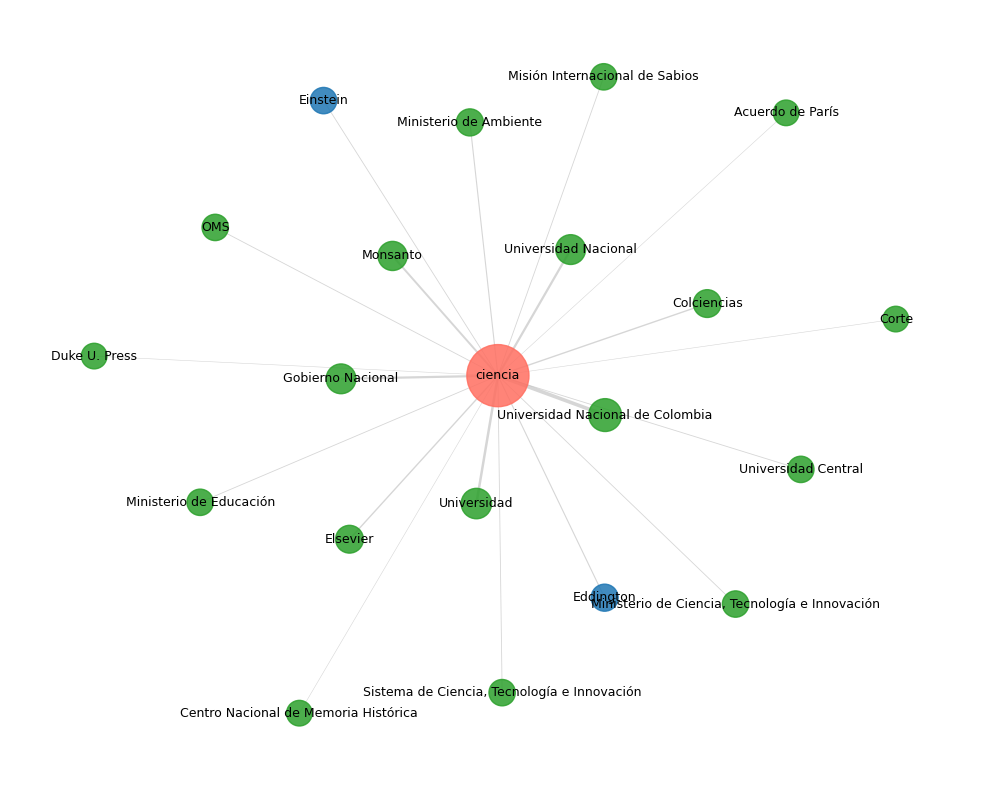

💾 Grafo guardado: ..\reports\ideas PAPERS\figures\grafo_ciencia_2019.png


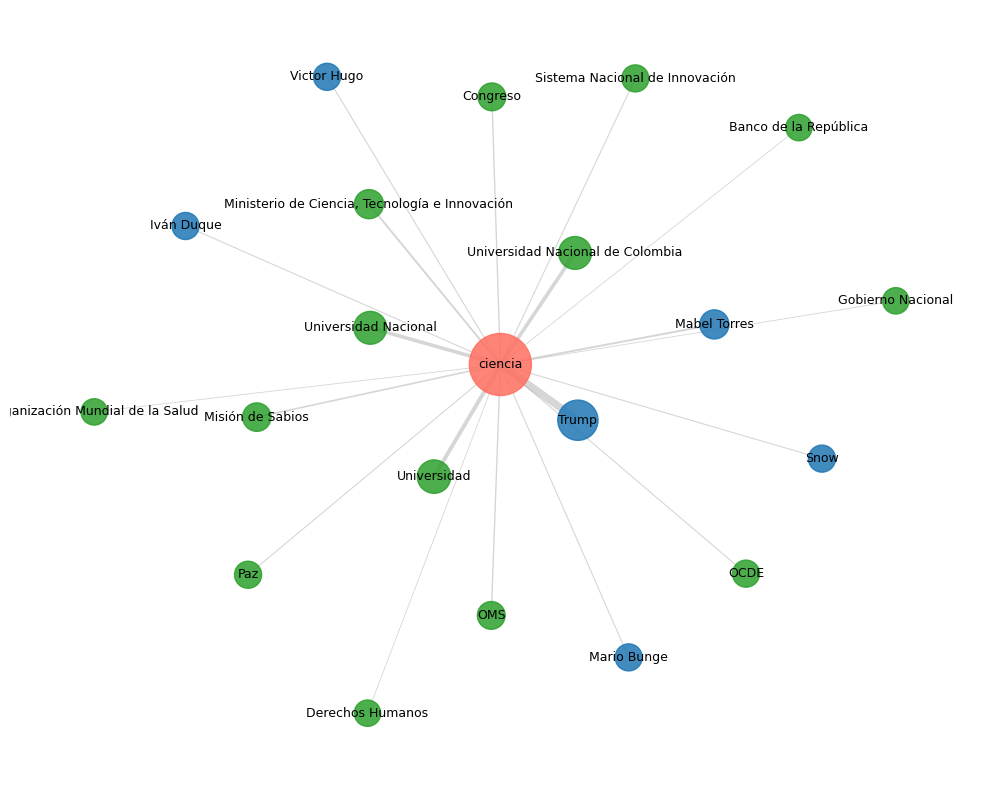

💾 Grafo guardado: ..\reports\ideas PAPERS\figures\grafo_ciencia_2020.png


In [31]:
# ---------- Crear carpeta de salida ----------
OUTPUT_DIR = Path(r"..\reports\ideas PAPERS\figures")
#OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Graficar un grafo por año ----------
años = sorted(freq["Año"].dropna().unique())

for año in años:
    top = freq[freq["Año"] == año].head(20)  # top entidades por año
    if top.empty:
        continue

    # Crear grafo
    G = nx.Graph()
    G.add_node("ciencia", size=2000, color="#FF6F61")  # rojo para el nodo central

    for _, row in top.iterrows():
        entidad = row["Entidad"]
        tipo = row["Tipo"]
        peso = row["frecuencia"]

        color = "#1f77b4" if tipo == "PER" else "#2ca02c"  # azul (PER), verde (ORG)
        G.add_node(entidad, size=300 + peso * 20, color=color)
        G.add_edge("ciencia", entidad, weight=peso)

    # Layout
    pos = nx.spring_layout(G, k=0.7, center=(0, 0), seed=42)

    # Dibujar
    plt.figure(figsize=(10, 8))
    #plt.title(f"Red de entidades asociadas a 'ciencia' – {año}", fontsize=14, pad=20)

    # Dibujar aristas
    nx.draw_networkx_edges(G, pos, alpha=0.4,
                           width=[d["weight"] * 0.2 for (_, _, d) in G.edges(data=True)],
                           edge_color="#999999")

    # Dibujar nodos con tamaños y colores
    node_colors = [G.nodes[n]["color"] for n in G.nodes()]
    node_sizes = [G.nodes[n]["size"] for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85)

    # Etiquetas
    nx.draw_networkx_labels(G, pos, font_size=9)

    plt.axis("off")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"grafo_ciencia_{año}.png", dpi=300)
    plt.show()
    print(f"💾 Grafo guardado: {OUTPUT_DIR / f'grafo_ciencia_{año}.png'}")
